In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from src_gypsum import utils
import flopy

In [2]:
# Usamos LaTeX para los tectos de la figura.
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  
    "font.serif": ["Computer Modern Roman"],
})

In [3]:
def data_recovery_excel(filename, tsel = 10):
    #
    # Concentraciones de los dos especies al tiempo 'tsel'
    c1 = pd.read_excel(filename, sheet_name='c_1').iloc[11:,tsel+5].to_numpy()     
    c2 = pd.read_excel(filename, sheet_name='c_2').iloc[11:,tsel+5].to_numpy()
    #
    # Solución analítica de los dos especies al tiempo 'tsel'
    an_tsel = 5 + tsel // 10 
    an_c1 = pd.read_excel(filename, sheet_name='An_C1').iloc[11:,an_tsel].to_numpy()
    an_c2 = pd.read_excel(filename, sheet_name='An_C2').iloc[11:,an_tsel].to_numpy()

    return c1, c2, an_c1, an_c2

In [4]:
# Cargamos el modelo de flujo
o_sim = flopy.mf6.MFSimulation.load(
    sim_ws="io_mf6/gwf_gwt_comp",
    verbosity_level=0)

# Obtenemos el objetos del modelo
o_gwt = o_sim.get_model("transport")

# Recuperamos las coordenadas del dominio
grid = o_gwt.modelgrid

# Recuperamos las coordenadas de los centros de las celdas de la malla
x = grid.xcellcenters[0] # centros de los volúmenes
print(x)

times = ["10d", "20d", "30d", "40d"]
print(times)

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
['10d', '20d', '30d', '40d']


In [5]:
nspec = 3
#
# Leer información de "u_init.dat"
with open("rt_workingDir/u_init_yeso.dat", "r") as f:
    spec_info = f.readlines()
key_string = "  Aqueous variable activity species:"
isp = utils.find_index(spec_info, key_string, 1)
spec_names = [l.split(": ")[1].strip() for l in spec_info[isp:isp+nspec]]
print(f"Especies: {spec_names}")

#
# Leer información de la simulación 
with open("rt_workingDir/gypsum_final_species.dat", "r") as f:
    lines = f.readlines()
steps = len(lines) // nspec
print(f"Pasos de tiempo: {steps}")

Especies: ['ca+2', 'cl-', 'so4-2']
Pasos de tiempo: 41


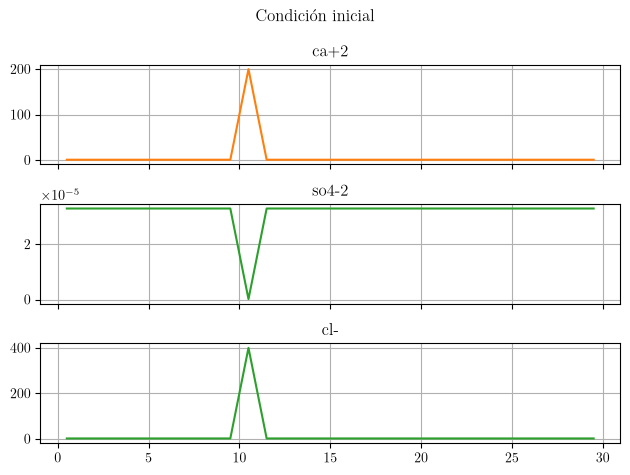

In [6]:
fig, ax = plt.subplots(3, 1, sharex = True)

ax[0].plot(x, [float(l) for l in lines[0].split()][1:], lw=1.5, ls = "-", color='C1')
ax[1].plot(x, [float(l) for l in lines[2].split()][1:], lw=1.5, ls = "-", color='C2')
ax[2].plot(x, [float(l) for l in lines[1].split()][1:], lw=1.5, ls = "-", color='C2')

ax[0].set_title(f"{spec_names[0]}")
ax[1].set_title(f"{spec_names[2]}")
ax[2].set_title(f"{spec_names[1]}")

ax[0].grid()
ax[1].grid()
ax[2].grid()

plt.suptitle("Condición inicial")
plt.tight_layout()
plt.show()

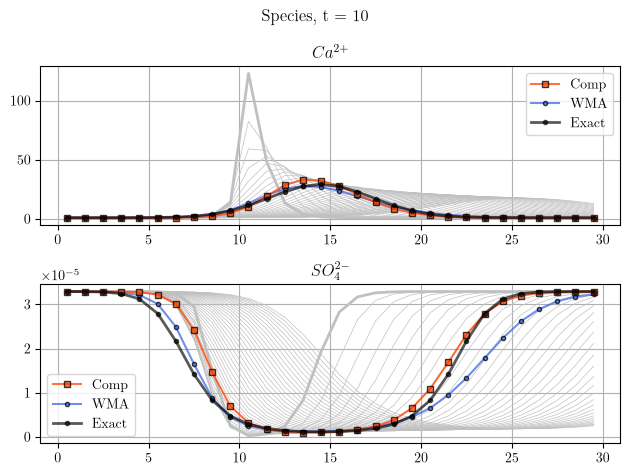

In [31]:
fig, ax = plt.subplots(2, 1)

# Graficación a apartir del paso 1.
for nt in range(1, 40, 1):
    lw = 2 if nt == 1 else 0.5
    ax[0].plot(x, [float(l) for l in lines[0 + nt * nspec].split()][1:], lw=lw, color='silver')
    ax[1].plot(x, [float(l) for l in lines[2 + nt * nspec].split()][1:], lw=lw, color='silver')
#    ax[2].plot(x, [float(l) for l in lines[1 + nt * nspec].split()][1:], lw=lw, color='silver')

tsel = 10

alpha = 0.75
markersize = 4

ax[0].plot(x, [float(l) for l in lines[0 + tsel * nspec].split()][1:], 
           lw=1.5, ls = "-", marker='s', markersize=markersize, markeredgecolor="black", 
           color='orangered', alpha=alpha, zorder = 5, label=f"Comp")
ax[1].plot(x, [float(l) for l in lines[2 + tsel * nspec].split()][1:], 
           lw=1.5, ls = "-", marker='s', markersize=markersize, markeredgecolor="black", 
           color='orangered', alpha=alpha, zorder = 5, label=f"Comp")
#ax[2].plot(x, [float(l) for l in lines[1 + tsel * nspec].split()][1:], 
#           lw=1.5, ls = "-", color='royalblue')

c1, c2, an_c1, an_c2 = data_recovery_excel("nr_analysis/comparativa_02.xlsx", tsel = tsel)

ax[0].plot(x, c1, marker='o', markersize=3, markeredgecolor="black", 
           alpha=alpha, color="royalblue", zorder = 4, label = f"WMA")
ax[1].plot(x, c2, marker='o', markersize=3, markeredgecolor="black", 
           alpha=alpha, color="royalblue", zorder = 4, label = f"WMA")
ax[0].plot(x, an_c1, ".-", lw = 2, color="black", label = f"Exact", alpha = 0.65, zorder = 6)
ax[1].plot(x, an_c2, ".-", lw = 2, color="black", label = f"Exact", alpha = 0.65, zorder = 6)

ax[0].set_title("$Ca^{2+}$")#f"{spec_names[0]}") 
ax[1].set_title("$SO_4^{2-}$")#f"{spec_names[2]}")
#ax[2].set_title(f"{spec_names[1]}")

ax[0].grid()
ax[1].grid()
#ax[2].grid()

ax[0].legend()
ax[1].legend()

plt.suptitle(f"Species, t = {tsel}")
plt.tight_layout()
plt.savefig("componentes_yeso.pdf")
plt.show()